## Step 4: Marker Gene Analysis.

Goal: Assign biological meaning to each cluster: tumor-like, immune-like, stromal-like, endothelial-like, or mixed/unknown.

## Load h5ad

In [24]:
import scanpy as sc
import pandas as pd
import squidpy as sq
import matplotlib.pyplot as plt

adata = sc.read_h5ad("../data/processed/breast_cancer_visium_clustered.h5ad")
adata.var_names_make_unique()
adata.raw=adata
sc.pp.scale(adata)

## Run marker genes:

C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning

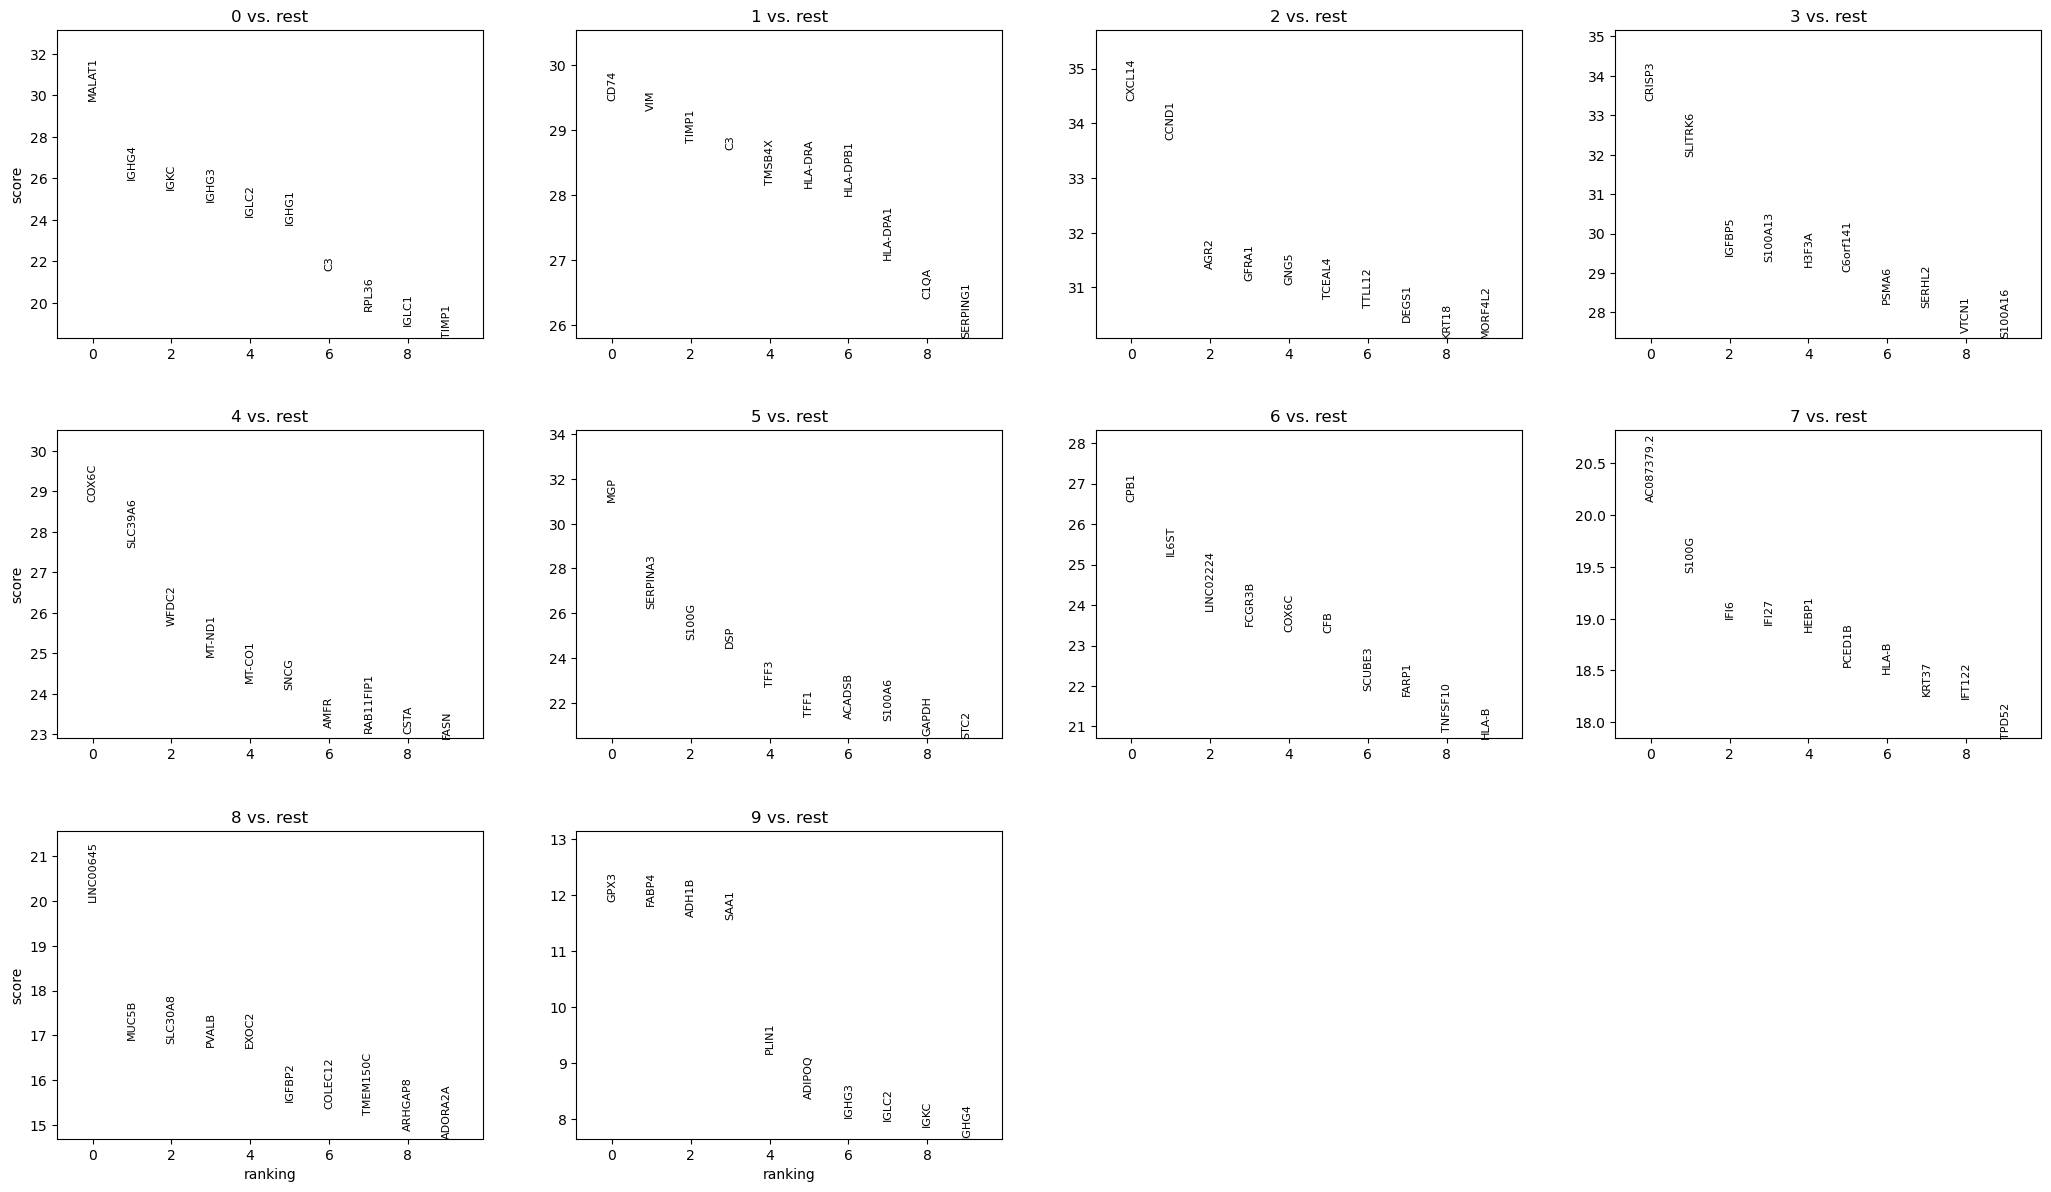

In [25]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_0_5",
    method="wilcoxon",
    use_raw=True
)

sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False,
    use_raw=True
)

## Then check known biology markers:

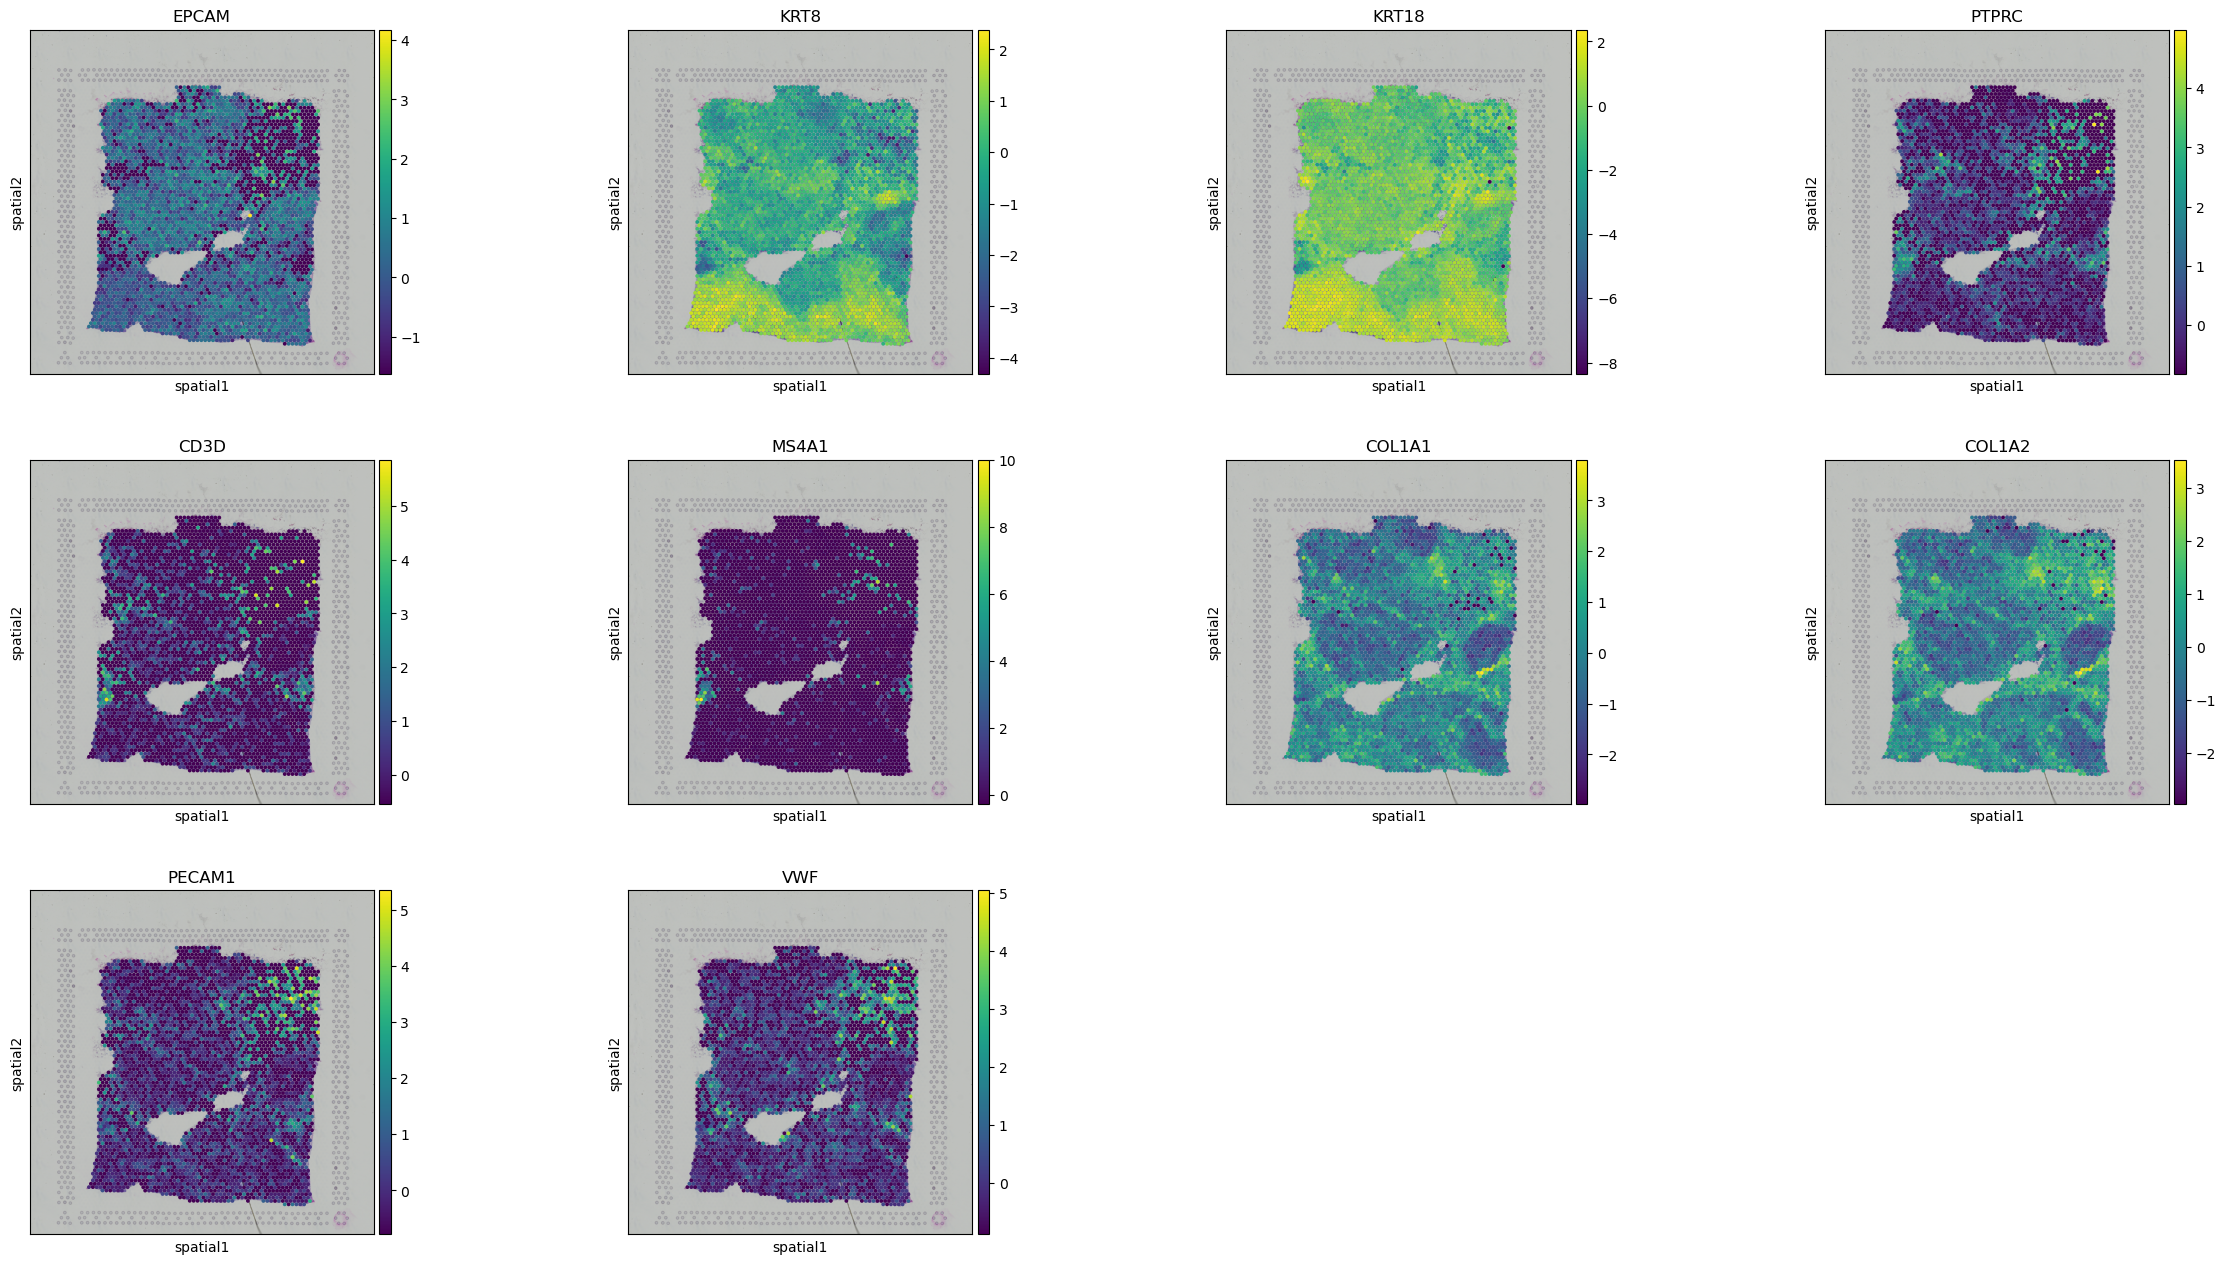

In [21]:
marker_genes = [
    "EPCAM",    # epithelial / tumor-like
    "KRT8",     # epithelial
    "KRT18",    # epithelial
    "PTPRC",    # immune/CD45
    "CD3D",     # T cells
    "MS4A1",    # B cells
    "COL1A1",   # stromal/fibroblast
    "COL1A2",   # stromal
    "PECAM1",   # endothelial
    "VWF"       # endothelial
]

available_markers = [g for g in marker_genes if g in adata.var_names]

sq.pl.spatial_scatter(
    adata,
    color=available_markers,
    size=1.5,
    cmap="viridis"
)

## Then plot by cluster:

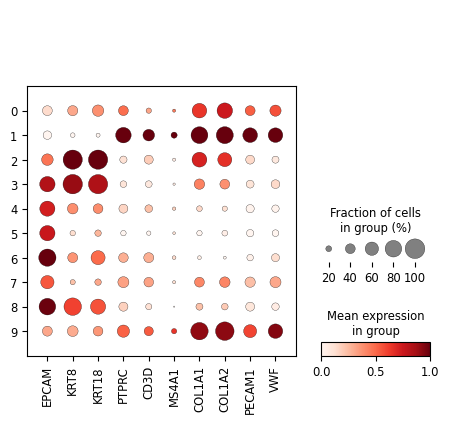

In [22]:
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="leiden_0_5",
    standard_scale="var"
)